In [56]:
import importlib
import Codex.tagr_heatmap_batcher as thb
importlib.reload(thb)


<module 'Codex.tagr_heatmap_batcher' from '/Users/aya/github/WWDR/Codex/tagr_heatmap_batcher.py'>

In [61]:
from pathlib import Path
from Codex import tagr_heatmap_batcher as thb

base = Path("/Users/aya/github/WWDR/8AM_ASM3_DB/Tagged_Datasets")
dest_dir = Path("/Users/aya/github/WWDR/8AM_ASM3_DB/Risk Heatmap")
dest_dir.mkdir(parents=True, exist_ok=True)

iteration_map = thb.available_iterations(base)
iterations = thb.resolve_iterations(None, iteration_map)

for iteration in iterations:
    matrix, labels = thb.load_iteration_matrix(base, iteration)
    out_path = dest_dir / f"tagr_heatmap_{iteration}.png"  # <-- unique filename
    thb.plot_iteration_heatmap(matrix, labels, iteration, output_path=out_path)


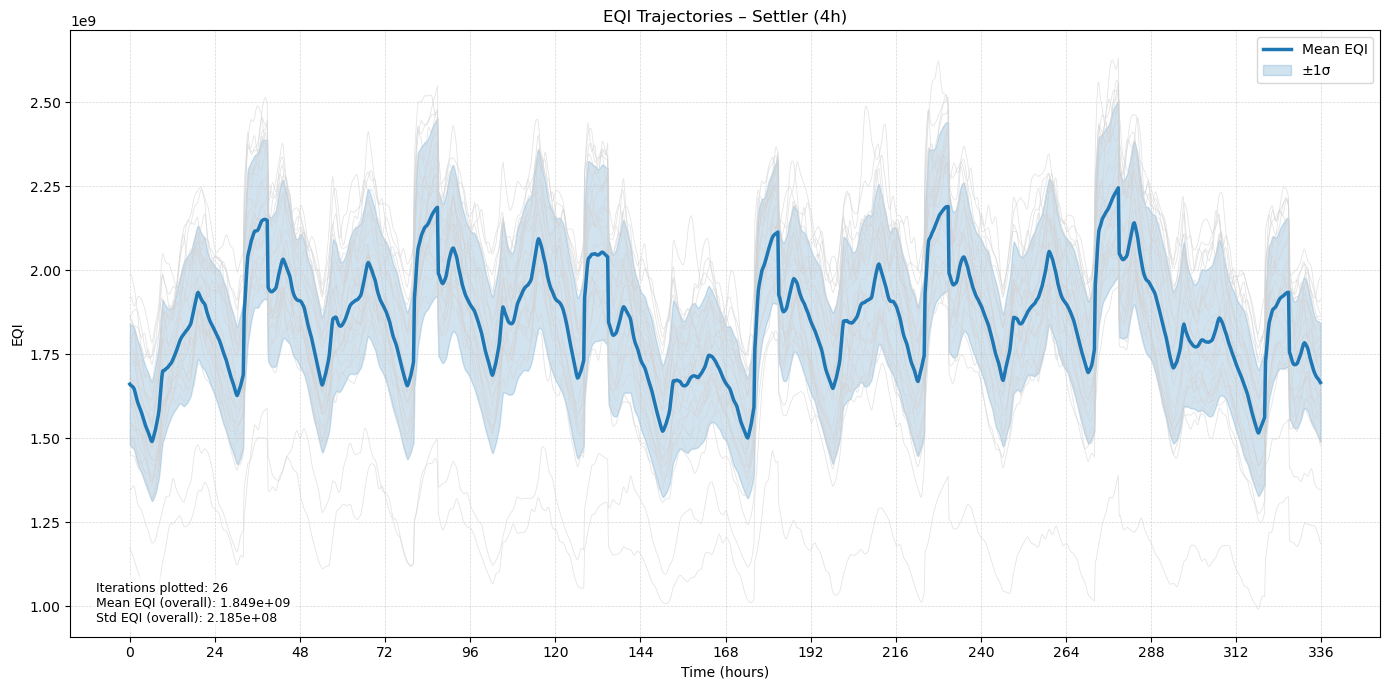

In [ ]:
import importlib
from pathlib import Path

import Codex.eqi_visualizer as eqi_viz
importlib.reload(eqi_viz)

base_dir = Path("/Users/aya/github/WWDR/8AM_ASM3_DB/Tagged_Datasets")
matrix, iterations = eqi_viz.collect_series(
    base_dir,
    experiment="4h",
    source="reactor4",
    iterations=None,  # or ['iter245', 'iter259']
)

save_plot = False  # flip to True when you want to write the PNG

output_path = Path("/Users/aya/github/WWDR/8AM_ASM3_DB/Risk Heatmap/eqi_settler_4h.png") if save_plot else None
eqi_viz.plot_eqi(matrix, iterations, experiment="4h", source="settler", output_path=output_path)


In [88]:
import importlib
from pathlib import Path

import Codex.pollu_vis as pollu_vis
importlib.reload(pollu_vis)

base_dir = Path("/Users/aya/github/WWDR/8AM_ASM3_DB/Tagged_Datasets")
nominal_dir = Path("/Users/aya/github/WWDR/8AM_ASM3_DB/Results_Nominal/ASM3_OutputDB")
source = "settler" # or any other entry from pollu_vis.SOURCES
experiments = ["4h", "5h", "6h", "7h"] # adjust or subset as needed
iterations = None # e.g. ["iter245", "iter259"] to limit

for exp in experiments:
    exp_root = base_dir / pollu_vis.EXPERIMENTS[exp] / "ASM3_OutputDB"
    nom_root = nominal_dir if nominal_dir.name == "ASM3_OutputDB" else nominal_dir / "ASM3_OutputDB"

diffs = pollu_vis.collect_differences(
    experiment_root=exp_root,
    nominal_root=nom_root,
    pattern=pollu_vis.SOURCES[source],
    iterations=iterations,
)
pct_data, series_len = pollu_vis.compute_percentiles(diffs)
pollu_vis.plot_percentiles(
    pct_data,
    series_len,
    experiment_label=exp,
    source_label=source,
    output_path=None,  # set to a Path(...) to save instead
    show=True,
)


TypeError: compute_eqi() got an unexpected keyword argument 'return_components'

In [89]:
import Codex.asm3_risk_tagging 
